In [19]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import os
print(os.getcwd())
#os.chdir("/Users/zheguan/DDA/Signature/Bit/notebooks/")

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from itertools import product
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import json

from src.testing import TestConfig
from src.testing.discriminators import AutoEvaluator, GeneralMMDDetector
from src.testing.discriminators.config import ProcessorConfig
from src.testing.experiment_functions.plot_result_functions import plot_path_test_threshold
from src.utils.Config import Config
from src.utils.auxiliary_classes.PathTransformer import PathTransformer, PathTransformerConfig
from src.utils.helper_functions.data_helper_functions import ema
from src.utils.helper_functions.global_helper_functions import get_project_root
from src.utils.helper_functions.plot_helper_functions import make_grid, golden_dimensions
from src.utils.helper_functions.test_helper_functions import get_memberships, get_sub_paths, get_grouped_paths, \
    get_alphas, time_ranges_from_subpaths, rank_by_size, wf_cluster_from_D, daily_regime_from_wf, load_and_cluster_all_matrices, compare_results, \
    ensure_regular_3d, spans_to_daily, load_D, agglom_precomputed, mds_embed, fit_prototypes_and_mapping, assign_by_prototypes, compress_with_rolling_vote, plot_price_with_cluster_background#, plot_and_save

/Users/zheguan/DDA/Signature/Bit/newrepo/Bit_regime_match/notebooks


In [5]:
import importlib
import src.utils.helper_functions.test_helper_functions as thf
importlib.reload(thf)

<module 'src.utils.helper_functions.test_helper_functions' from '/Users/zheguan/DDA/Signature/Bit/newrepo/Bit_regime_match/notebooks/src/utils/helper_functions/test_helper_functions.py'>

## Prepare the BTC-USD dataset

In [6]:
yf_interval = "1d"

symbols = ["BTC-USD"]
start_date = "2021-01-01"
end_date   = "2024-06-30"

data       = yf.download(" ".join([s for s in symbols]), start=start_date, end=end_date, interval=yf_interval)
#vix_data   = yf.download("BVOL-USD", start="2020-05-05", end="2024-12-31")["Close"]
data_clean = data.dropna()
data_clean = data_clean[["Close"]]
np_data = data_clean.copy().to_numpy()
tickers = data_clean[["Close"]]["Close"].columns.values

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_8785/1477190293.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data       = yf.download(" ".join([s for s in symbols]), start=start_date, end=end_date, interval=yf_interval)
[*********************100%***********************]  1 of 1 completed


### Financial Time Series Analysis with Path Transformations and MMD Evaluation

In [7]:
# A SIMPLE EXAMPLE CONFIG
#symbols = ["BTC-USD"]
interval   = "1d"
price_data = yf.download(" ".join(symbols), start=start_date, end=end_date, interval=interval)
#vix_data   = yf.download("BVOL-USD", start="2020-05-05", end="2024-12-31")["Close"]


close_prices = price_data["Close"].dropna()
dates        = close_prices.index.to_numpy()
assets       = close_prices.columns.to_numpy()

price_array  = close_prices.to_numpy()  # shape: (T, N)


timestamps = dates.astype("datetime64[s]").astype("int64")
trajectory_data = np.column_stack([timestamps, price_array]).astype(np.float64)
original_timestamps = pd.to_datetime(timestamps, unit="s")

n_steps = 5
n_paths = 20
offset  = 0
dt = 1/252 


path_transformer_config = PathTransformerConfig()
path_transformer_config.set_transformations({
    "standardise_path_transform":    (True,  0, {"s_type": "initial"}),
    "time_difference_transform":     (False, 0, {}),
    "time_normalisation_transform":  (True,  0, {}),
    "difference_transform":          (False, 0, {}),
    "translation_transform":         (False, 0, {}), 
    "scaling_transform":             (False, 0, {"sigmas": [dt**-0.5 for _ in range(len(tickers))]}),
    "cumulant_transform":            (False, 2, {}),
    "increment_transform":           (False, 2, {}),
    "lead_lag_transform":            (False, 3, {}),
    "invisibility_transform":        (False, 4, {}),
})
pt = PathTransformer(path_transformer_config)

processor_config = ProcessorConfig()
processor_config.override_args({
    "autoevaluator_kwargs": Config(**{
        "metric_kwargs": Config(**{
            "kernel_type": "rbf",
            "metric_type": "mmd",
            "sigmas": [1],
            "dyadic_orders": [2],
            "lambd": 1.0
        }),
        "n_scores": 200,
        "evaluator_kwargs": Config(**{
            "lags": [-4, -8, -12],
            "threshold_method": "bootstrap"
        })
    }),
    "device": "cuda" if torch.cuda.is_available() else "cpu"
})

processor_config.alpha_value = 0.9
sub_paths = get_sub_paths(trajectory_data, n_steps=n_steps, offset=offset)
mmd_cluster = get_grouped_paths(sub_paths, n_paths)
sub_paths_t_real   = pt.transform_paths(sub_paths.copy())
grouped_paths = get_grouped_paths(sub_paths_t_real, n_paths=n_paths)
test_config = TestConfig()
test_config.override_args({
    "n_steps": n_steps,
    "n_paths": n_paths,
    "offset": offset,
    "weight_factor": 1.0
})

evaluator = AutoEvaluator(
    path_transformer=pt,
    processor_config=processor_config,
    test_config=test_config
)


num_groups = grouped_paths.shape[0]
out_path = get_project_root() / "data/pairwise_distance_matrix.npy"

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_8785/2816412495.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(" ".join(symbols), start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  1 of 1 completed
100%|██████████████████████████████████████| 255/255 [00:00<00:00, 56129.49it/s]

Metric initialized. MMD1, kernel = rbf, dyadic_order = 2


## Pair_Wise Distance Matrix for Sensitivity Analysis

In [15]:
# Parameter grids
n_steps_list  = [5, 8, 10, 15]
n_paths_list  = [8, 12, 16, 20]
offset_fixed  = 0

out_dir = get_project_root() / "dataall"
out_dir.mkdir(parents=True, exist_ok=True)

# Outer progress bar over all (n_steps, n_paths) combinations
all_combos = list(product(n_steps_list, n_paths_list))
pbar_all = tqdm(all_combos, desc="All combos", position=0, leave=True, dynamic_ncols=True)

for n_steps_i, n_paths_i in pbar_all:
    pbar_all.set_postfix({"n_steps": n_steps_i, "n_paths": n_paths_i, "offset": offset_fixed})

    try:
        # Build subpaths
        sub_paths = get_sub_paths(trajectory_data, n_steps=n_steps_i, offset=offset_fixed)

        # Skip if subpaths are ragged or too few
        if isinstance(sub_paths, (list, tuple)) or (isinstance(sub_paths, np.ndarray) and sub_paths.dtype == object):
            tqdm.write(f"Skip: steps={n_steps_i}, paths={n_paths_i}, off={offset_fixed} (ragged sub_paths)")
            continue
        if sub_paths.shape[0] < n_paths_i:
            tqdm.write(f"Skip: steps={n_steps_i}, paths={n_paths_i}, off={offset_fixed} (too few subpaths: {sub_paths.shape[0]} < {n_paths_i})")
            continue

        # Transform and group subpaths
        sub_paths_t = pt.transform_paths(sub_paths.copy())
        grouped_paths = get_grouped_paths(sub_paths_t, n_paths=n_paths_i)

        if isinstance(grouped_paths, np.ndarray) and grouped_paths.dtype == object:
            tqdm.write(f"Skip: steps={n_steps_i}, paths={n_paths_i}, off={offset_fixed} (ragged grouped_paths)")
            continue

        num_groups = getattr(grouped_paths, "shape", [0])[0]
        if num_groups <= 0:
            tqdm.write(f"Skip: steps={n_steps_i}, paths={n_paths_i}, off={offset_fixed} (no groups)")
            continue

        # Configure evaluator for this combination
        test_config_i = TestConfig()
        test_config_i.override_args({
            "n_steps": n_steps_i,
            "n_paths": n_paths_i,
            "offset": offset_fixed,
            "weight_factor": 1.0
        })
        evaluator_i = AutoEvaluator(
            path_transformer=pt,
            processor_config=processor_config,
            test_config=test_config_i
        )

        # Compute distance matrix
        dist_matrix = np.zeros((num_groups, num_groups), dtype=np.float64)
        total_pairs = num_groups * (num_groups + 1) // 2
        with tqdm(total=total_pairs,
                  desc=f"steps={n_steps_i}, paths={n_paths_i}, off={offset_fixed}",
                  position=1, leave=False, dynamic_ncols=True, mininterval=0.3) as pbar_pairs:
            for i in range(num_groups):
                for j in range(i, num_groups):
                    d = evaluator_i.metric(grouped_paths[i], grouped_paths[j])
                    dist_matrix[i, j] = d
                    dist_matrix[j, i] = d
                    pbar_pairs.update(1)

        out_npy = out_dir / f"pairwise_distance_matrix_steps{n_steps_i}_paths{n_paths_i}_offset{offset_fixed}.npy"
        np.save(out_npy.as_posix(), dist_matrix)

        meta = {
            "n_steps": n_steps_i,
            "n_paths": n_paths_i,
            "offset": offset_fixed,
            "num_groups": int(num_groups),
        }
        with open(out_npy.with_suffix(".meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        tqdm.write(f"Saved: {out_npy.name} | shape={dist_matrix.shape}")

    except Exception as e:
        tqdm.write(f"Skip: steps={n_steps_i}, paths={n_paths_i}, off={offset_fixed} | error={repr(e)}")

tqdm.write("All combinations finished.")

All combos:   0%|                                        | 0/16 [00:00<?, ?it/s]

100%|██████████████████████████████████████| 255/255 [00:00<00:00, 46770.49it/s]

Metric initialized. MMD1, kernel = rbf, dyadic_order = 2


steps=5, paths=8, off=0:   0%|                        | 0/30876 [00:00<?, ?it/s]

Saved: pairwise_distance_matrix_steps5_paths8_offset0.npy | shape=(248, 248)


...

Saved: pairwise_distance_matrix_steps15_paths16_offset0.npy | shape=(70, 70)


100%|████████████████████████████████████████| 85/85 [00:00<00:00, 40325.28it/s]

Metric initialized. MMD1, kernel = rbf, dyadic_order = 2


steps=15, paths=20, off=0:   0%|                       | 0/2211 [00:00<?, ?it/s]

Saved: pairwise_distance_matrix_steps15_paths20_offset0.npy | shape=(66, 66)
All combinations finished.


Process all settings:   0%|          | 0/16 [00:00<?, ?it/s]

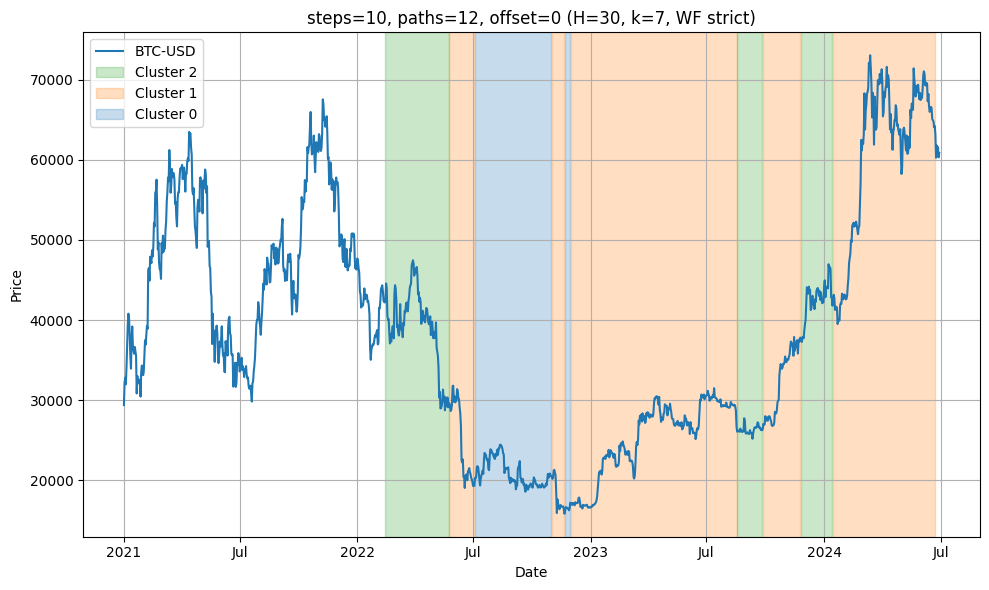

✓ done s10_p12_o0_H30_wfstrict: groups=116, first_label_at_group=29


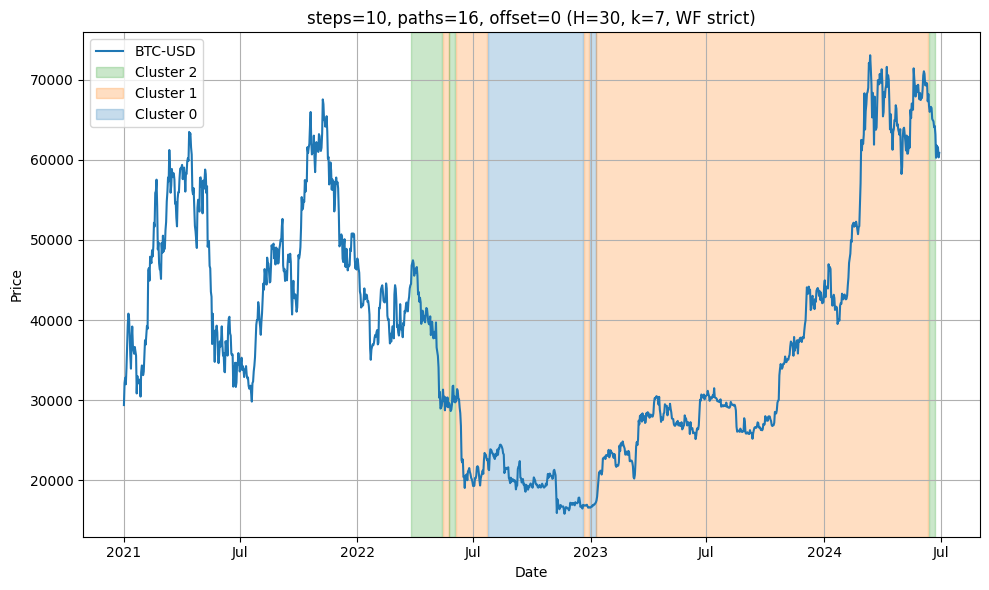

✓ done s10_p16_o0_H30_wfstrict: groups=112, first_label_at_group=29


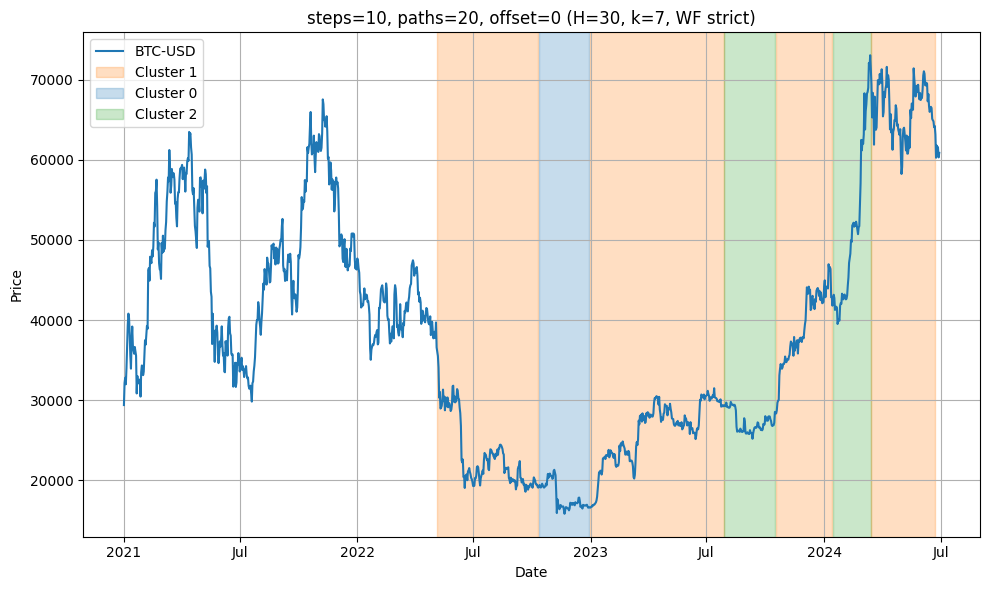

✓ done s10_p20_o0_H30_wfstrict: groups=108, first_label_at_group=29


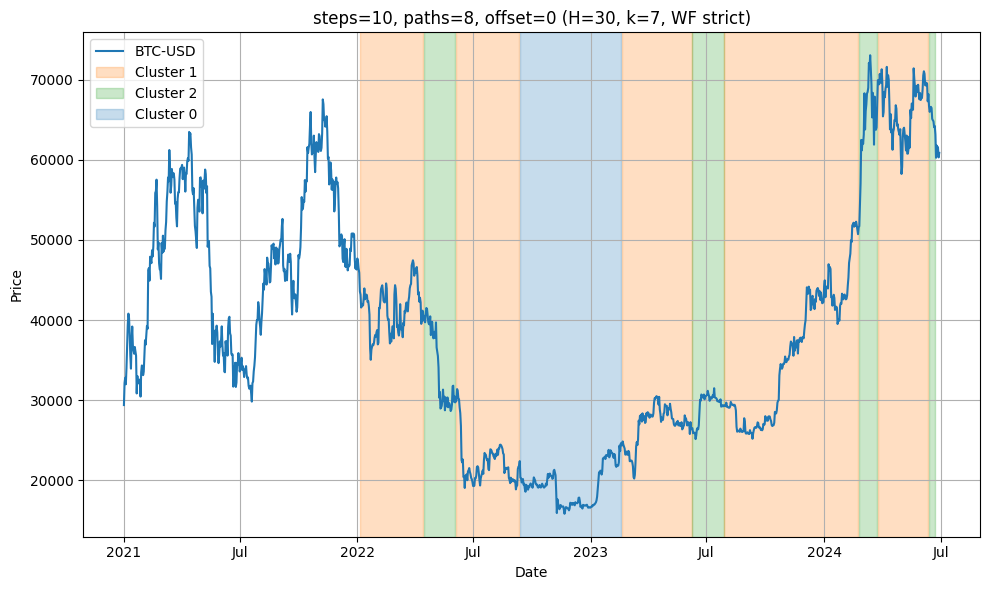

✓ done s10_p8_o0_H30_wfstrict: groups=120, first_label_at_group=29


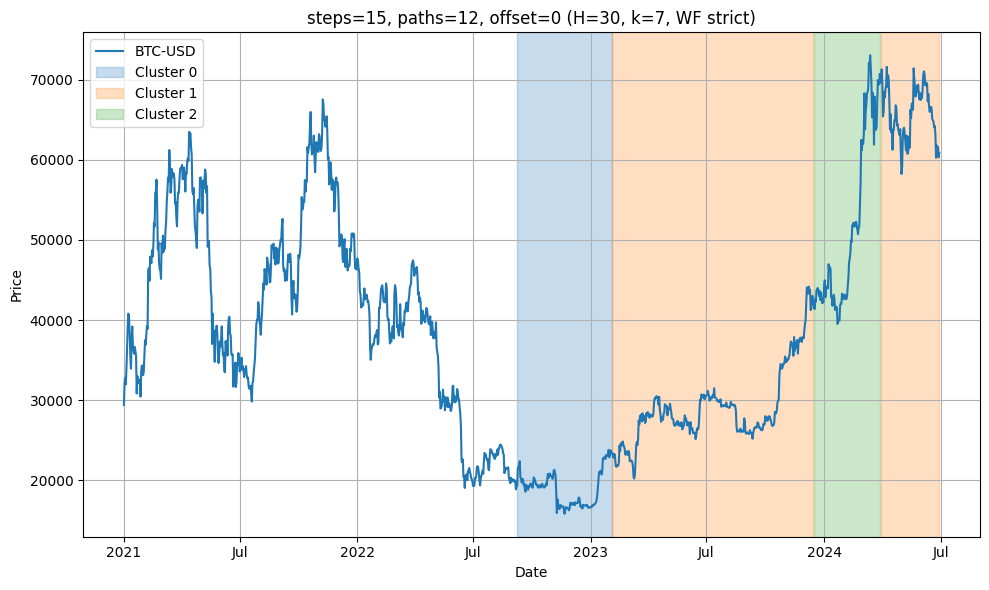

✓ done s15_p12_o0_H30_wfstrict: groups=74, first_label_at_group=29


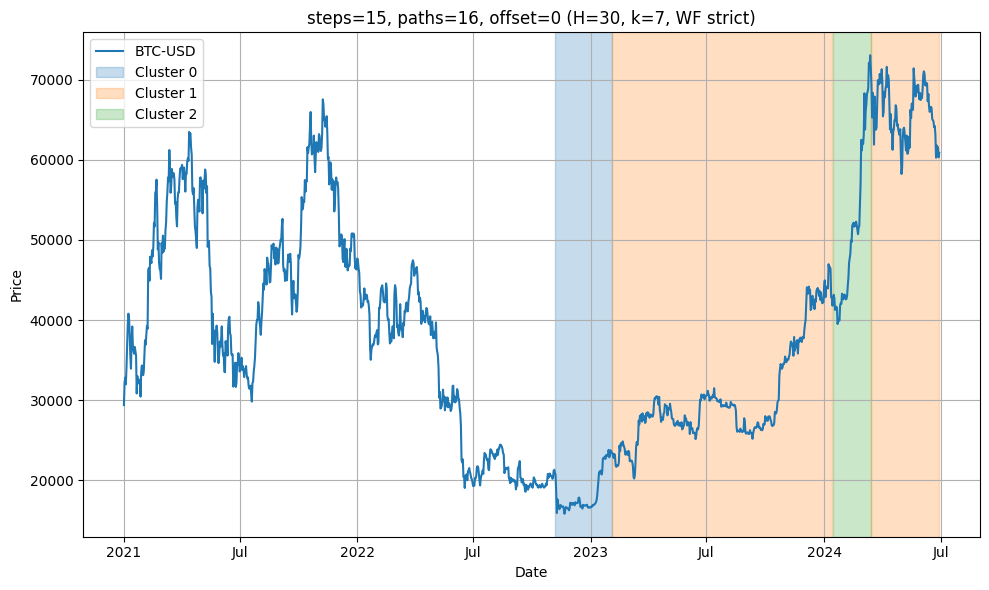

✓ done s15_p16_o0_H30_wfstrict: groups=70, first_label_at_group=29


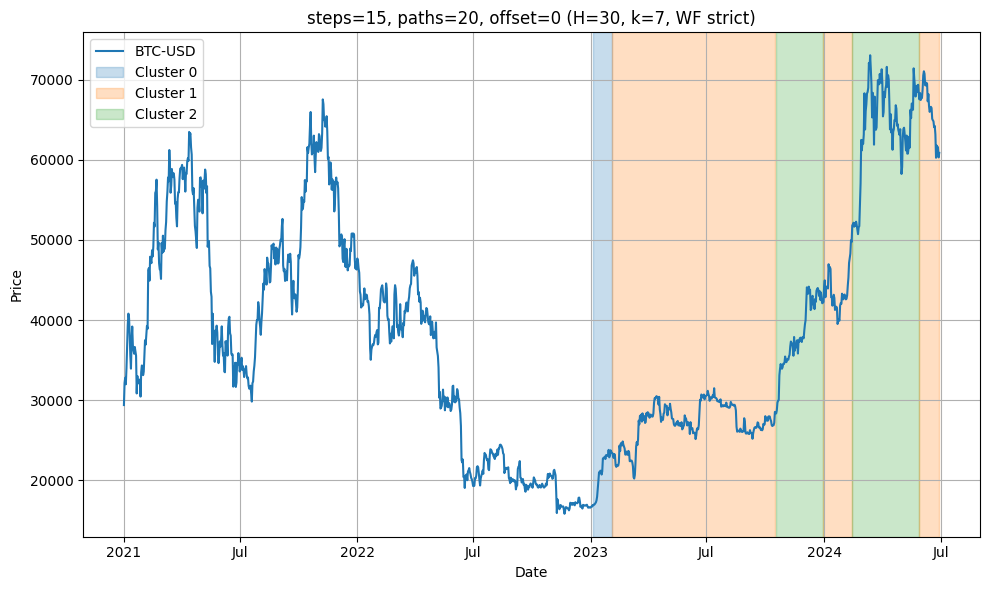

✓ done s15_p20_o0_H30_wfstrict: groups=66, first_label_at_group=29


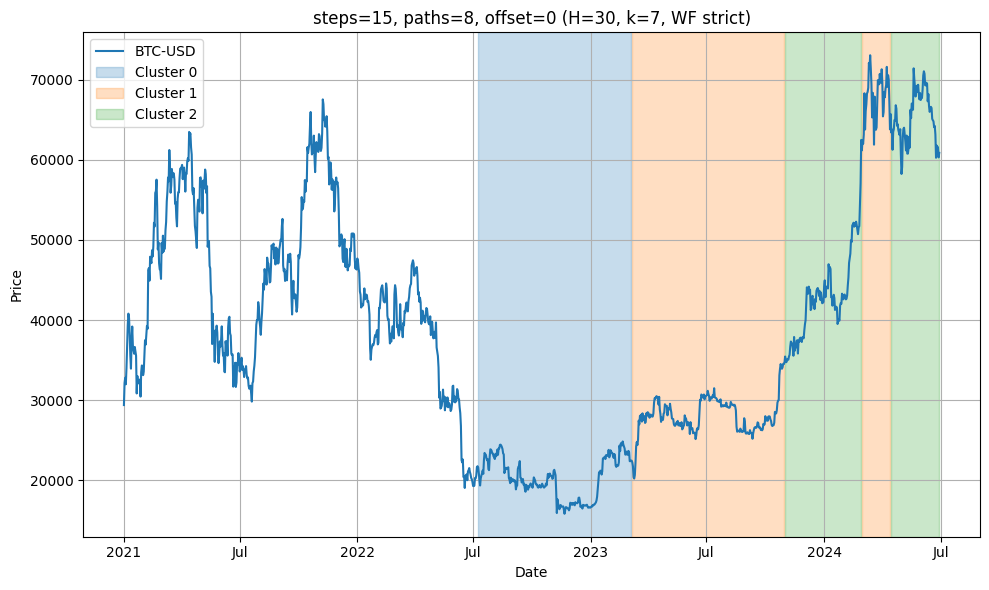

✓ done s15_p8_o0_H30_wfstrict: groups=78, first_label_at_group=29


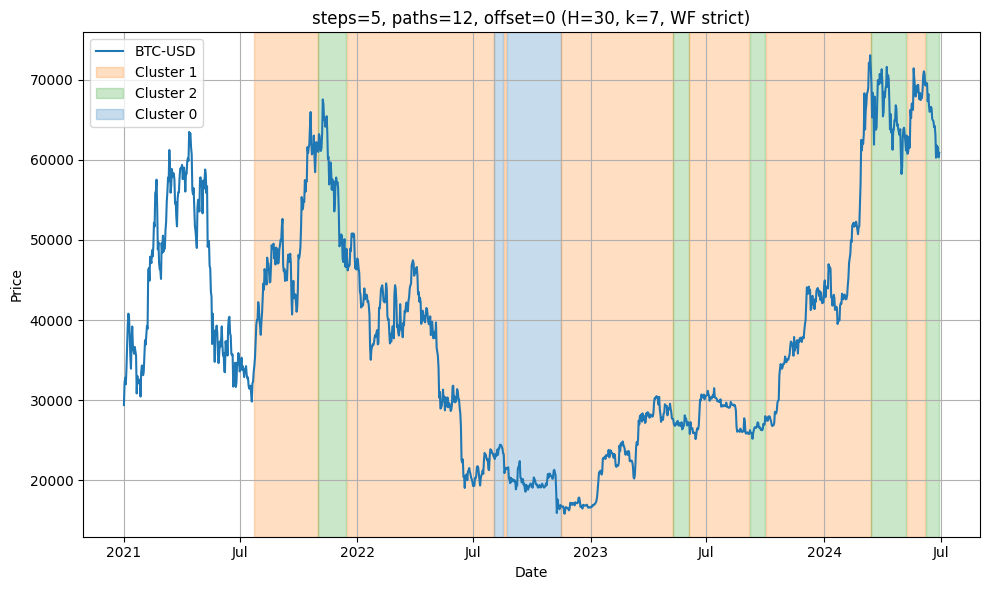

✓ done s5_p12_o0_H30_wfstrict: groups=244, first_label_at_group=29


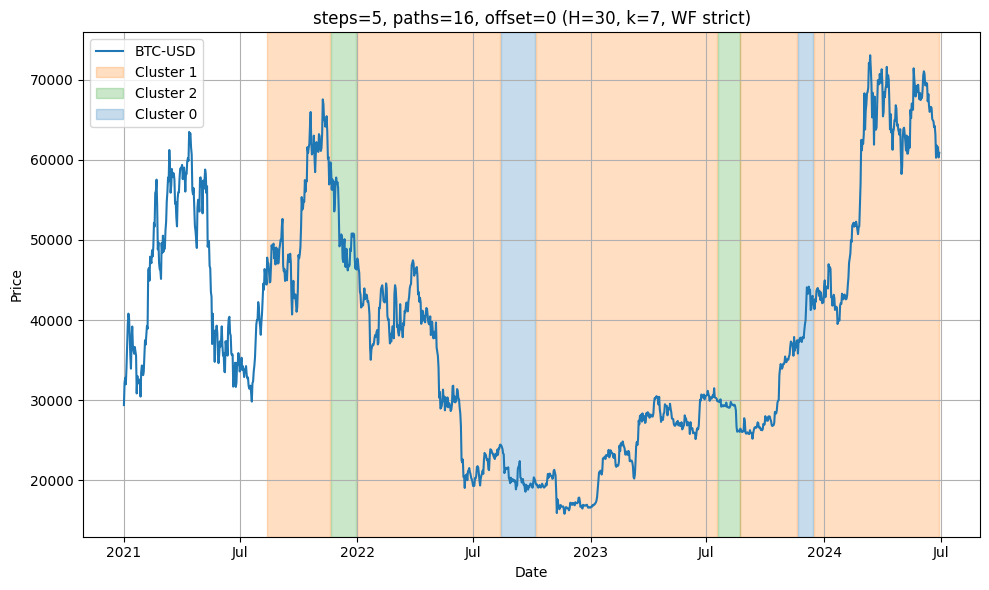

✓ done s5_p16_o0_H30_wfstrict: groups=240, first_label_at_group=29


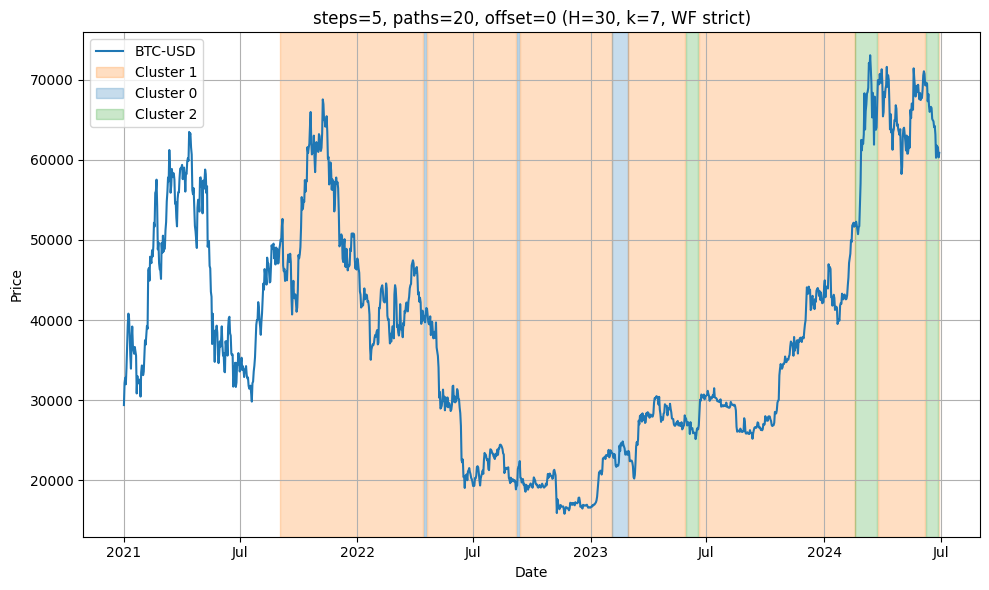

✓ done s5_p20_o0_H30_wfstrict: groups=236, first_label_at_group=29


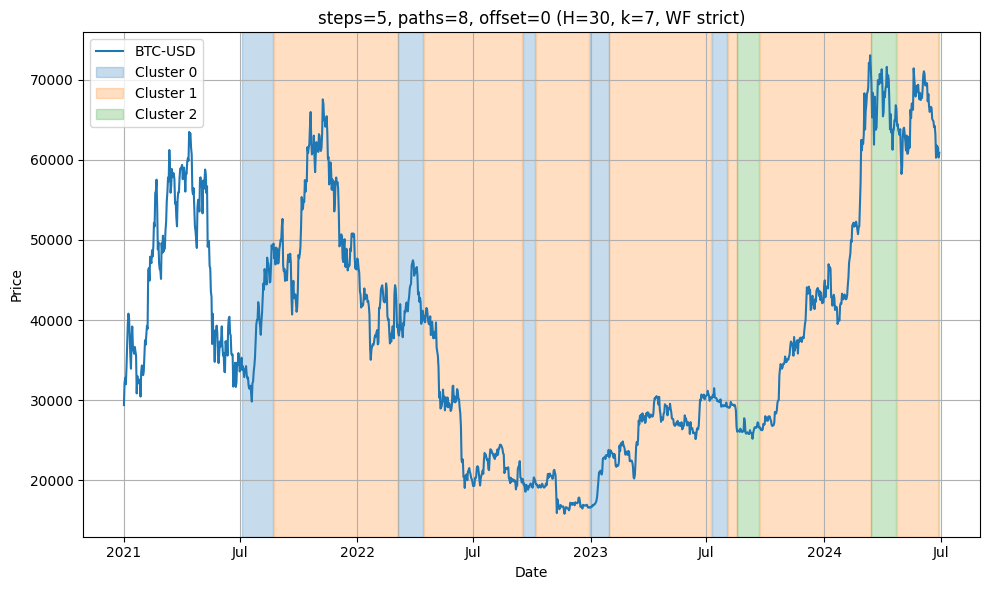

✓ done s5_p8_o0_H30_wfstrict: groups=248, first_label_at_group=29


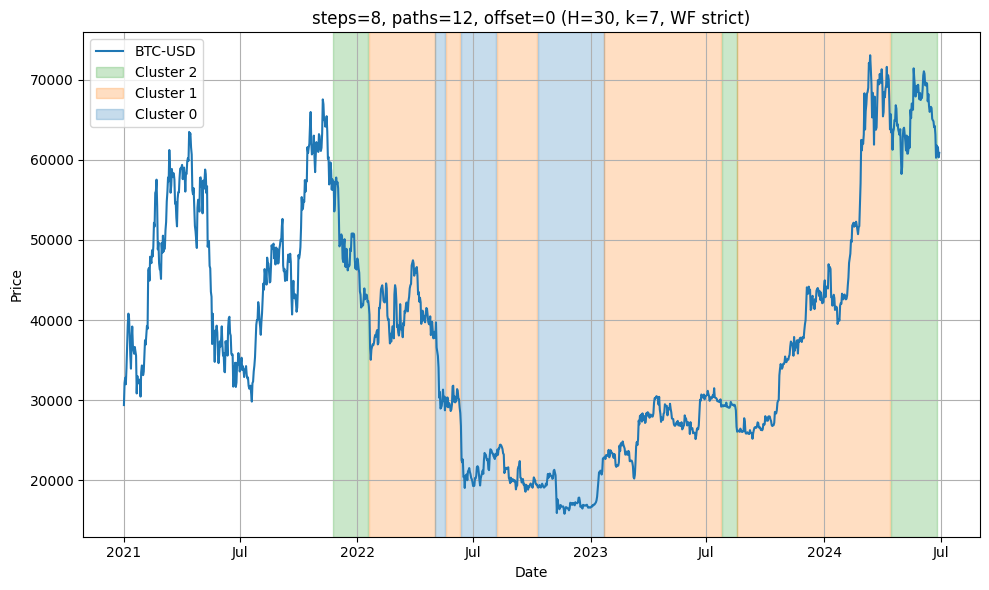

✓ done s8_p12_o0_H30_wfstrict: groups=148, first_label_at_group=29


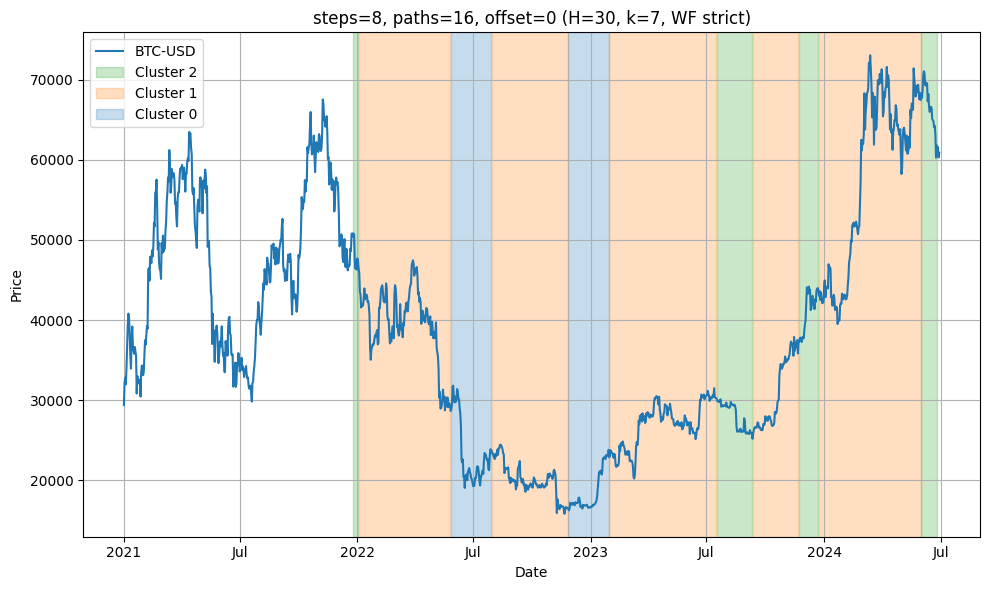

✓ done s8_p16_o0_H30_wfstrict: groups=144, first_label_at_group=29


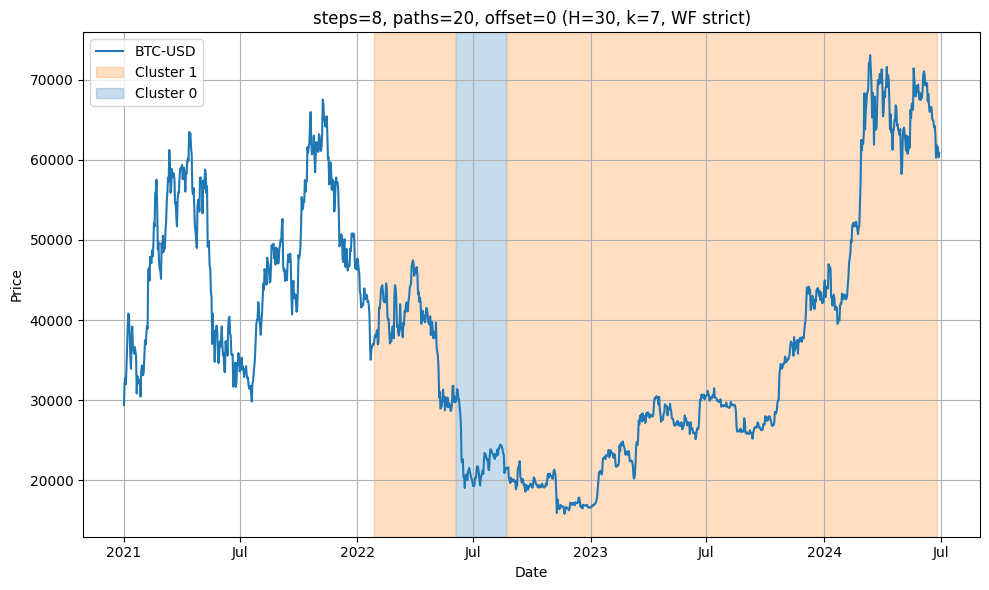

✓ done s8_p20_o0_H30_wfstrict: groups=140, first_label_at_group=29


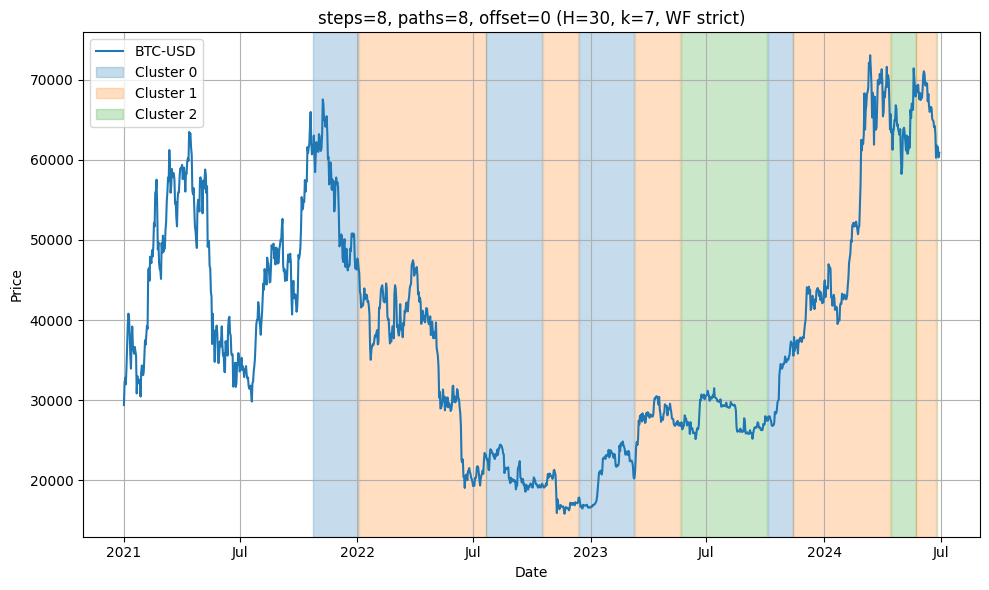

✓ done s8_p8_o0_H30_wfstrict: groups=152, first_label_at_group=29


In [40]:

import json, re, numpy as np, pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# ===== Utilities =====

def ensure_regular_3d(paths) -> np.ndarray:
    """Coerce a list/array of 2D paths (time × dim) to a regular (N, L, d) float array by truncating to the shortest length."""
    arr = np.array(paths, dtype=object)
    if arr.dtype != object:
        return np.asarray(arr, dtype=np.float64, copy=False)
    lens, dims = [], []
    for p in arr:
        p = np.asarray(p)
        if p.ndim != 2:
            raise ValueError(f"Each path must be 2D (time x dim), got {p.shape}")
        lens.append(p.shape[0]); dims.append(p.shape[1])
    if len(set(dims)) != 1:
        raise ValueError(f"Inconsistent path dimension: {set(dims)}")
    L, d = int(min(lens)), int(dims[0])
    out = np.empty((len(arr), L, d), dtype=np.float64)
    for i, p in enumerate(arr):
        out[i] = np.asarray(p, dtype=np.float64)[:L]
    return out

def get_sub_paths(path: np.ndarray, n_steps: int, offset: int) -> np.ndarray:
    """Slice one long path into overlapping subpaths of length n_steps with stride (n_steps - offset)."""
    total_sub_paths = int(len(path) / (n_steps - offset))
    sub_paths = np.array([
        path[i * (n_steps - offset):i * (n_steps - offset) + n_steps] for i in range(total_sub_paths)
    ])
    return sub_paths

def time_ranges_from_subpaths(subpaths, n_paths: int) -> pd.DataFrame:
    """
    For each group k, take:
      start = start time of subpath k
      end   = end time of subpath (k + n_paths - 1)
    Assumes subpath[..., 0] holds epoch timestamps in seconds.
    """
    sp = ensure_regular_3d(subpaths)  # (N, L, d)
    N = sp.shape[0]
    G = N - n_paths + 1
    if G <= 0:
        raise ValueError(f"Not enough subpaths: N={N}, n_paths={n_paths}")
    starts = [pd.to_datetime(int(sp[k,              0, 0]), unit="s") for k in range(G)]
    ends   = [pd.to_datetime(int(sp[k + n_paths - 1, -1, 0]), unit="s") for k in range(G)]
    return pd.DataFrame({"start_time": starts, "end_time": ends})

def load_D(pathlike):
    """Load and sanitize a pairwise distance matrix: zero diag, symmetrize, fix NaN/inf with max finite, clamp negatives to 0."""
    D = np.load(pathlike)
    D = np.asarray(D, float)
    np.fill_diagonal(D, 0.0)
    D = 0.5 * (D + D.T)
    D[~np.isfinite(D)] = np.nanmax(D[np.isfinite(D)]) if np.isfinite(D).any() else 0.0
    D[D < 0] = 0.0
    return D

# ===== Forward returns & in-window training =====

def _group_forward_returns(df_ranges, px: pd.Series, H: int, start_from: str = "next", return_index=False):
    """
    Compute H-step forward log-returns from each group's end. Optionally return index pairs (i0, iH) for visibility filtering.
    start_from: "next" uses the bar strictly after group end; "same" allows same-bar start.
    """
    px = px if isinstance(px, pd.Series) else px.iloc[:, 0]
    lp = np.log(px.dropna())
    idx = lp.index
    end = pd.to_datetime(df_ranges["end_time"])
    i0 = idx.searchsorted(end, side="left" if start_from == "same" else "right")
    iH = i0 + H
    r = np.full(len(df_ranges), np.nan, dtype=float)
    ok = (iH < len(idx))
    r[ok] = (lp.values[iH[ok]] - lp.values[i0[ok]])
    return (r, i0, iH) if return_index else r

def _fit_window_prototypes(
    D, window_idx, eligible_idx, rH, n_clusters=3, min_count=10,
    tau_pos=0.0, tau_neg=0.0, use_median=False
):
    """
    Cluster only on eligible samples (with visible forward returns) → pick medoids → map clusters to {0:bear,1:neutral,2:bull}
    based on the average/median forward return of eligible samples in each cluster.
    """
    if len(eligible_idx) < n_clusters:
        return None, None, None
    Dt = D[np.ix_(eligible_idx, eligible_idx)]
    try:
        mdl = AgglomerativeClustering(metric="precomputed", linkage="complete",
                                      n_clusters=n_clusters).fit(Dt)
    except TypeError:
        mdl = AgglomerativeClustering(affinity="precomputed", linkage="complete",
                                      n_clusters=n_clusters).fit(Dt)
    labs = mdl.labels_

    # Medoids: cluster member with minimal row-sum distance within the cluster
    medoid_idx, proto2cluster = [], {}
    for c in range(n_clusters):
        members = np.asarray(eligible_idx)[labs == c]
        if len(members) == 0:
            medoid_idx.append(None); continue
        sub = D[np.ix_(members, members)]
        m = int(members[np.argmin(sub.sum(axis=1))])
        medoid_idx.append(m); proto2cluster[m] = c

    # Map clusters to directional labels using eligible samples' forward returns (default neutral=1)
    mapping = {c: 1 for c in range(n_clusters)}
    effects, counts = {}, {}
    for c in range(n_clusters):
        vals = rH[np.asarray(eligible_idx)[labs == c]]
        vals = vals[np.isfinite(vals)]
        counts[c] = int(len(vals))
        if counts[c] > 0:
            effects[c] = float(np.median(vals) if use_median else np.mean(vals))
    eligible_c = {c: effects[c] for c in effects.keys() if counts.get(c, 0) >= min_count}
    if eligible_c:
        order = sorted(eligible_c.items(), key=lambda x: x[1])  # worst → best
        worst_c, worst_mean = order[0]
        best_c,  best_mean  = order[-1]
        if best_mean  > tau_pos: mapping[best_c]  = 2  # bull
        if worst_mean < tau_neg: mapping[worst_c] = 0  # bear
    return medoid_idx, proto2cluster, mapping

def strict_walkforward_labeling_by_prototypes(
    D, df_ranges, price_series,
    window_groups=30, n_clusters=3, H=30, start_from="next",
    min_count=10, tau_pos=0.0, tau_neg=0.0, use_median=False
):
    """
    Strict WF loop for g = window_groups-1..G-1:
      • Train ONLY on historical window (including g) with visible H-step returns, EXCLUDING the current group g.
      • Use trained medoids/mapping to label ONLY the current group g.
    Returns df_wf with columns: [start_time, end_time, cluster_id, dir_label].
    """
    D = np.asarray(D, float)
    np.fill_diagonal(D, 0.0)
    D = 0.5 * (D + D.T)
    G = D.shape[0]
    assert len(df_ranges) == G

    rH, i0, iH = _group_forward_returns(df_ranges, price_series, H, start_from=start_from, return_index=True)
    px_idx = price_series.dropna().index

    cluster_id = np.full(G, np.nan)
    dir_label  = np.full(G, np.nan)

    for g in range(window_groups - 1, G):
        window_idx = np.arange(g - window_groups + 1, g + 1)
        end_g = pd.to_datetime(df_ranges.iloc[g]["end_time"])
        cut_pos = px_idx.searchsorted(end_g, side="right")  # upper bound of prices visible at time g
        mask = (iH[window_idx] < cut_pos) & (window_idx != g)
        eligible_idx = window_idx[mask]
        if len(eligible_idx) < n_clusters:
            continue
        medoids, proto2cluster, mapping = _fit_window_prototypes(
            D, window_idx, eligible_idx, rH,
            n_clusters=n_clusters, min_count=min_count,
            tau_pos=tau_pos, tau_neg=tau_neg, use_median=use_median
        )
        if not medoids or all(m is None for m in medoids):
            continue
        meds = [m for m in medoids if m is not None]
        d_to_med = D[g, meds]
        nearest  = meds[int(np.argmin(d_to_med))]
        c_id     = proto2cluster.get(nearest, np.nan)
        d_lab    = mapping.get(c_id, 1) if np.isfinite(c_id) else np.nan
        cluster_id[g] = c_id
        dir_label[g]  = d_lab

    out = df_ranges.copy()
    out["cluster_id"] = cluster_id
    out["dir_label"]  = dir_label
    return out

# ===== Signal compression & plotting =====

def compress_with_rolling_vote(df_wf, k: int = 3, half_life_groups: float | None = None, freq: str = "D"):
    """
    Daily label via rolling vote over the most recent k completed groups (optional exponential weights).
    Returns a non-overlapping interval DataFrame with ["start","end","cluster"] at the chosen frequency.
    """
    df = df_wf.dropna(subset=["cluster"]).copy().sort_values("end_time")
    if df.empty:
        return pd.DataFrame(columns=["start","end","cluster"])
    ends = pd.to_datetime(df["end_time"]).dt.floor("D")
    labs = df["cluster"].astype(int).to_numpy()
    idx = pd.date_range(ends.iloc[0], ends.iloc[-1], freq=freq)

    daily_label, ptr = [], 0
    for t in idx:
        while ptr < len(ends) and ends.iloc[ptr] <= t:
            ptr += 1
        if ptr == 0:
            daily_label.append(np.nan); continue
        s = max(0, ptr - k)
        cand = labs[s:ptr]
        if half_life_groups is None:
            vals, counts = np.unique(cand, return_counts=True)
            vote_winner = vals[np.argmax(counts)]
        else:
            n = cand.shape[0]
            ages = np.arange(n)  # 0=oldest, n-1=newest
            lam = np.log(2) / max(half_life_groups, 1e-6)
            w = np.exp(lam * (ages - (n-1)))  # newest weight = 1
            scores = {u: w[(cand == u)].sum() for u in np.unique(cand)}
            vote_winner = max(scores.items(), key=lambda x: x[1])[0]
        daily_label.append(vote_winner)

    s = pd.Series(daily_label, index=idx).dropna()
    spans, cur = [], None
    for t, lab in s.items():
        if lab != cur:
            if cur is not None:
                spans.append((start, prev, cur))
            cur = lab; start = t
        prev = t
    spans.append((start, prev, cur))
    return pd.DataFrame(spans, columns=["start","end","cluster"])

def spans_to_daily(spans: pd.DataFrame, freq: str = "D") -> pd.Series:
    """Expand interval labels back to a daily series of ints."""
    if spans.empty:
        return pd.Series(dtype=float)
    chunks = []
    for _, row in spans.iterrows():
        idx = pd.date_range(pd.to_datetime(row["start"]), pd.to_datetime(row["end"]), freq=freq)
        chunks.append(pd.Series(int(row["cluster"]), index=idx))
    s = pd.concat(chunks).sort_index()
    return s[~s.index.duplicated(keep="last")].rename("dir_label")

def plot_price_with_cluster_background(price_series, df_clusters, title="", label_col="cluster",
                                       label_names=None, save_path=None):
    """Plot price with semi-transparent background spans for cluster segments; optionally save to file."""
    import matplotlib.dates as mdates
    if hasattr(price_series, "columns"): price_series = price_series.iloc[:, 0]
    df = df_clusters.copy()
    if {"start","end"}.issubset(df.columns):
        df = df.rename(columns={"start":"start_time","end":"end_time"})
    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(price_series.index, price_series.values, lw=1.5, label=price_series.name or "Price")
    df = df.dropna(subset=[label_col])
    uniq = sorted(df[label_col].unique())
    cmap = plt.get_cmap("tab10")
    color_map = {cl: cmap(int(i) % 10) for i, cl in enumerate(uniq)}
    for _, row in df.iterrows():
        lab = int(row[label_col])
        ax.axvspan(row["start_time"], row["end_time"], color=color_map[lab], alpha=0.25,
                   label=(label_names.get(lab, f"{label_col} {lab}") if label_names else f"{label_col} {lab}"))
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left")
    ax.set_title(title)
    ax.set_xlabel("Date"); ax.set_ylabel("Price"); ax.grid(True)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig

# ===== Runtime parameters  =====

data_dir   = Path("/Users/zheguan/DDA/Signature/Bit/newrepo/Bit_regime_match/notebooks/dataall")
offset_fix = 0
mode       = "rolling"   # marker only; no branching
window_groups = 30
min_window    = 10
n_clusters    = 3
k_vote        = 7


price_series = (data_clean["Close"].iloc[:,0]
                if hasattr(data_clean["Close"], "columns") else data_clean["Close"])
price_series = price_series.dropna()

# Output dirs
out_dir     = data_dir / "wf_outputs"
images_dir  = out_dir / "images"
signals_dir = out_dir / "signals"
out_dir.mkdir(exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)
signals_dir.mkdir(parents=True, exist_ok=True)

# ===== Main loop: run strict WF for each (steps, paths, offset) setting =====

pat = re.compile(r"pairwise_distance_matrix_steps(\d+)_paths(\d+)_offset(\d+)\.npy$")
files = sorted(data_dir.glob("pairwise_distance_matrix_steps*_paths*_offset*.npy"))

for f in tqdm(files, desc="Process all settings"):
    # Parse params (prefer .meta.json if present)
    meta_path = f.with_suffix(".meta.json")
    if meta_path.exists():
        with open(meta_path, "r") as fh:
            m = json.load(fh)
        n_steps_i = int(m["n_steps"]); n_paths_i = int(m["n_paths"]); offset_i = int(m["offset"])
    else:
        m = pat.search(f.name)
        if not m:
            print(f"Skip {f.name}: cannot parse params")
            continue
        n_steps_i, n_paths_i, offset_i = map(int, m.groups())

    if offset_i != offset_fix:
        continue

    # Holding horizon H: fixed here, or set H_i = int(n_steps_i)
    H_i = 30

    # Load distance matrix & align time ranges
    D = load_D(f)
    sub_paths_all = get_sub_paths(trajectory_data, n_steps=n_steps_i, offset=offset_i)
    df_ranges = time_ranges_from_subpaths(sub_paths_all, n_paths=n_paths_i)
    if len(df_ranges) != D.shape[0]:
        print(f"SKIP {f.name}: groups mismatch ({len(df_ranges)} vs {D.shape[0]})")
        continue

    # Strict WF: label only the CURRENT group (earliest window_groups-1 are NaN)
    df_wf = strict_walkforward_labeling_by_prototypes(
        D, df_ranges, price_series,
        window_groups=window_groups, n_clusters=n_clusters, H=H_i, start_from="next",
        min_count=10, tau_pos=0, tau_neg=-0, use_median=False
    )

    # Daily signal via rolling vote (no look-ahead)
    df_for_vote = df_wf.rename(columns={"dir_label": "cluster"})
    spans = compress_with_rolling_vote(df_for_vote, k=k_vote)         # ["start","end","cluster"]
    daily = spans_to_daily(spans)                                      # index=dates, values=0/1/2

    # Plot & save
    key = f"s{n_steps_i}_p{n_paths_i}_o{offset_i}_H{H_i}_wfstrict"
    spans_plot = spans.rename(columns={"start":"start_time","end":"end_time"})
    fig = plot_price_with_cluster_background(
        price_series=price_series,
        df_clusters=spans_plot.assign(cluster=spans_plot["cluster"]),
        label_col="cluster",
        label_names={0:"Cluster 0", 1:"Cluster 1", 2:"Cluster 2"},
        title=f"steps={n_steps_i}, paths={n_paths_i}, offset={offset_i} (H={H_i}, k={k_vote}, WF strict)",
        save_path=(images_dir / f"{key}.png")
    )
    plt.show()
    plt.close(fig)

    # Save CSVs
    df_wf.to_csv    (signals_dir / f"wf_current_only_{key}_rolling.csv", index=False)   # group-level: labels only for current group
    spans.to_csv    (signals_dir / f"spans_dir_{key}_k{k_vote}_rolling.csv", index=False)
    daily.to_csv    (signals_dir / f"daily_dir_{key}_k{k_vote}_rolling.csv", header=["dir_label"])

    print(f"✓ done {key}: groups={D.shape[0]}, first_label_at_group={window_groups-1}")


In [9]:
data_dir = get_project_root() / "dataall"   # directory containing the distance matrices
# res = load_and_cluster_all_matrices(
#     data_dir=data_dir,
#     trajectory_data=trajectory_data,
#     window_groups=30,       # walk-forward window size
#     n_clusters=3,           # number of clusters
#     k_vote=5,               # majority vote among last k groups
#     offset=0,
# )
# summary, ari = compare_results(res)

# display(summary)   
# display(ari)       # ARI similarity matrix, closer to 1 means higher agreement

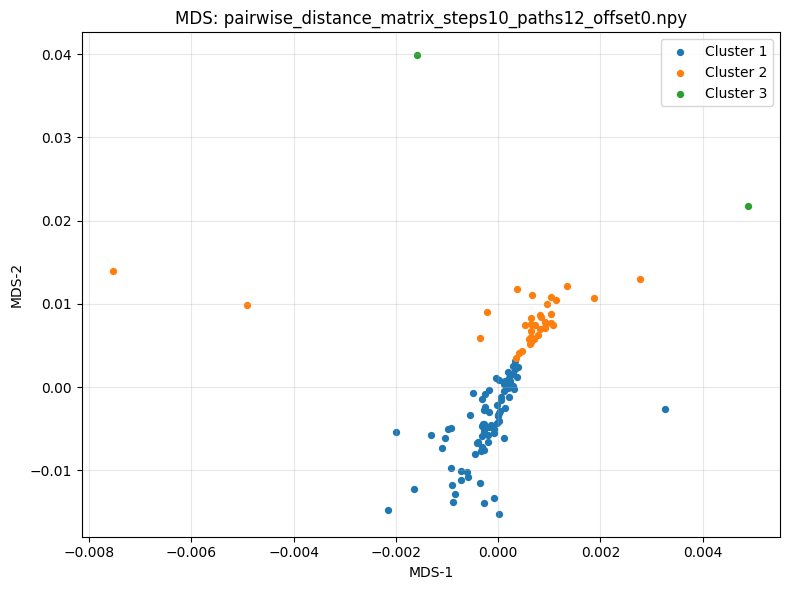

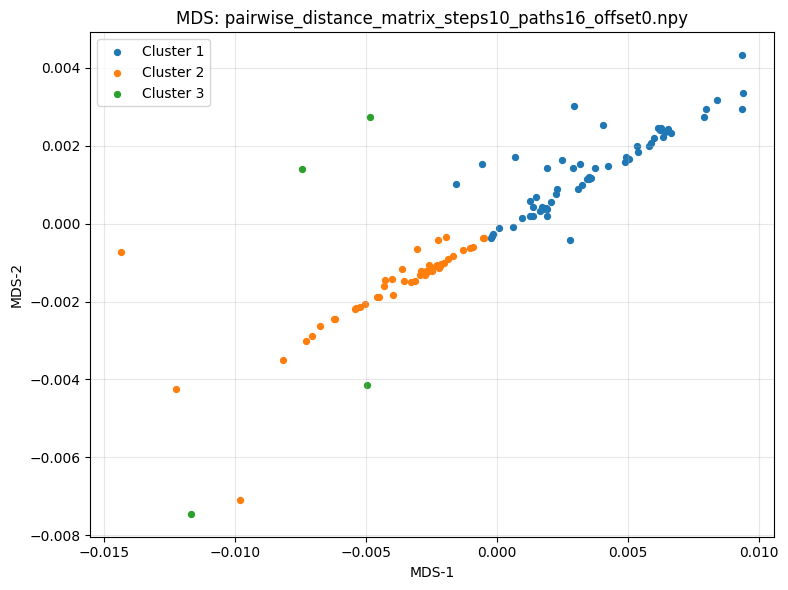

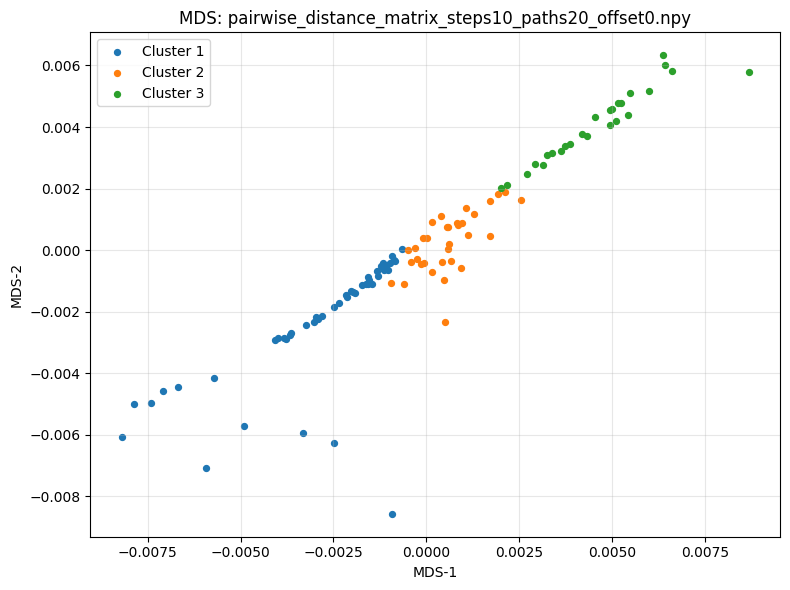

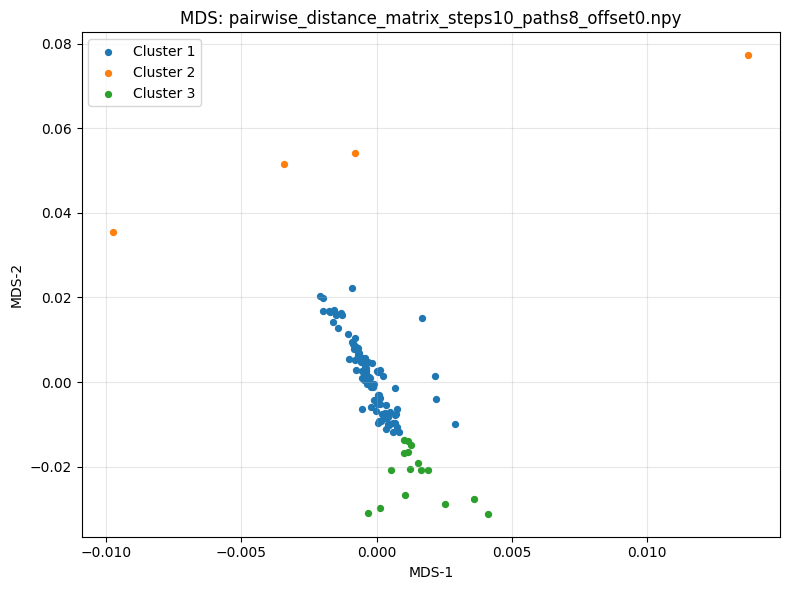

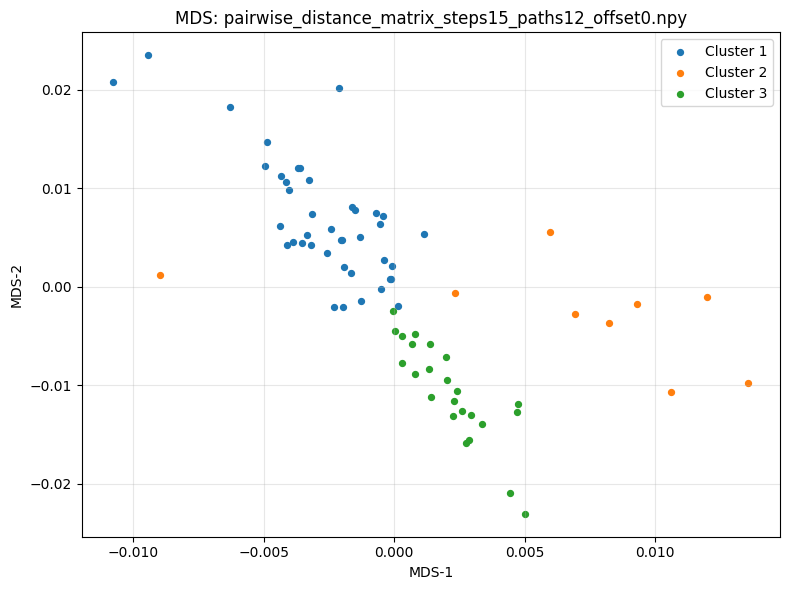

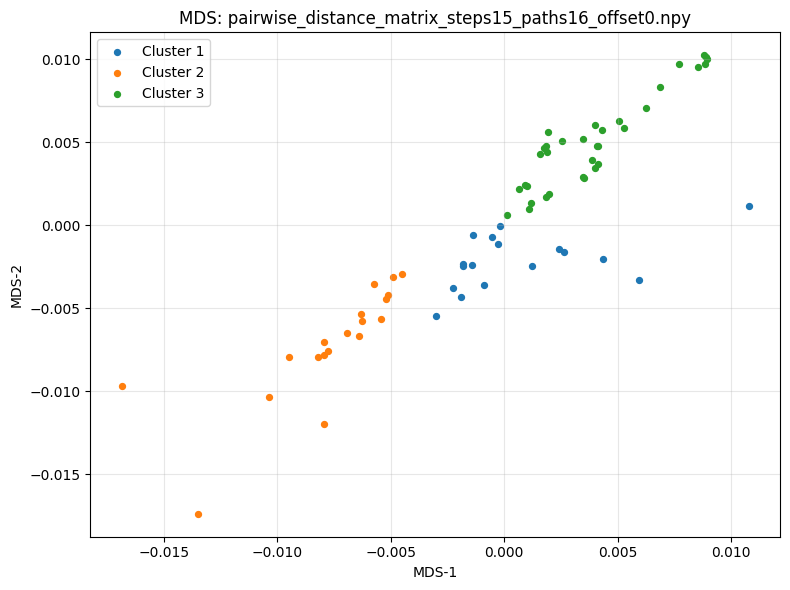

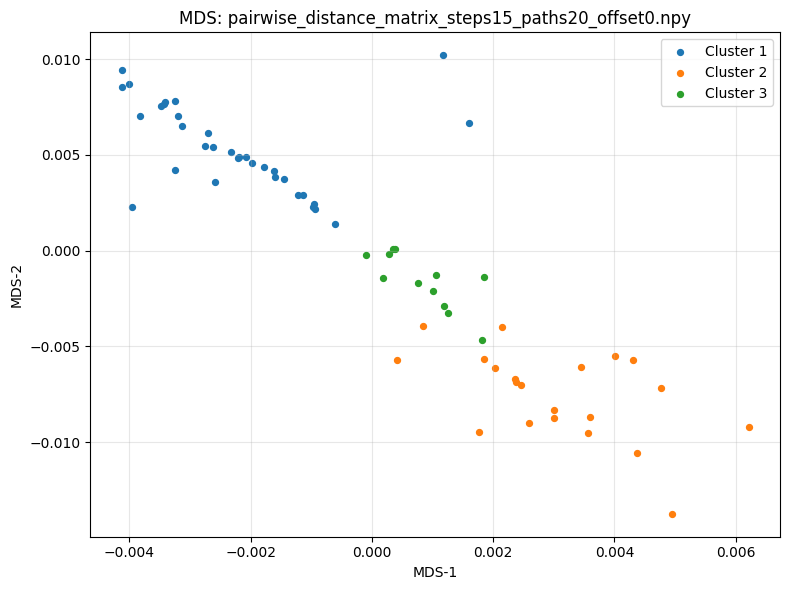

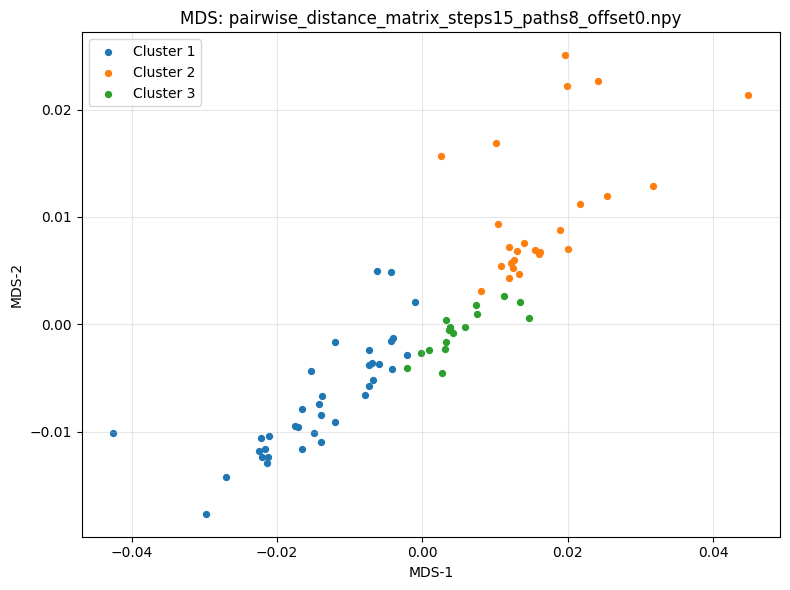

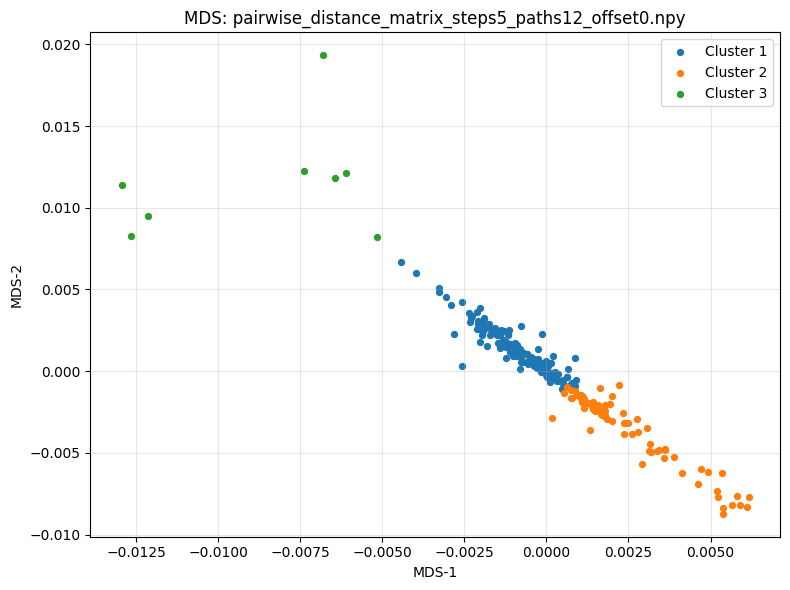

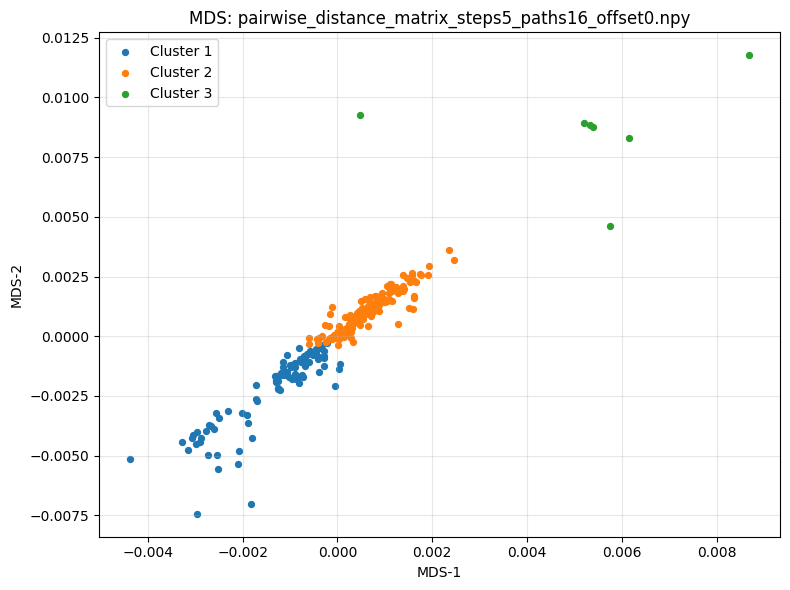

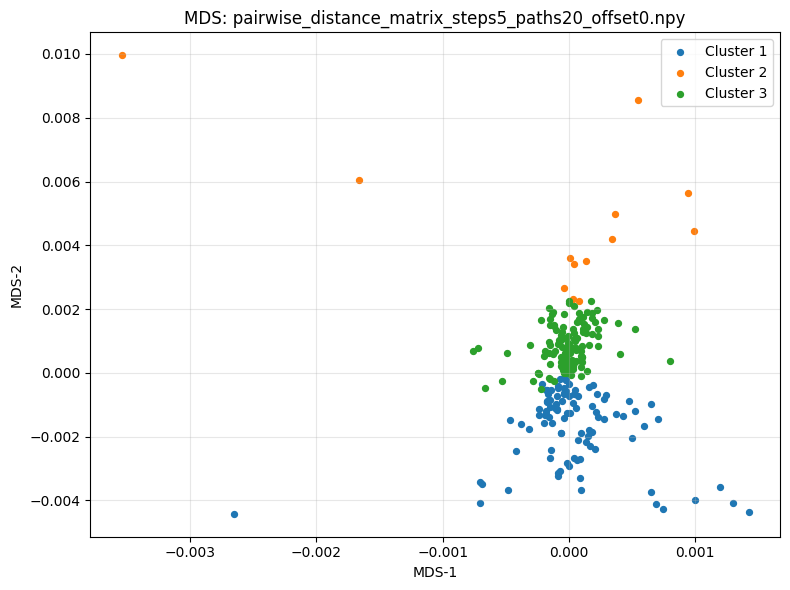

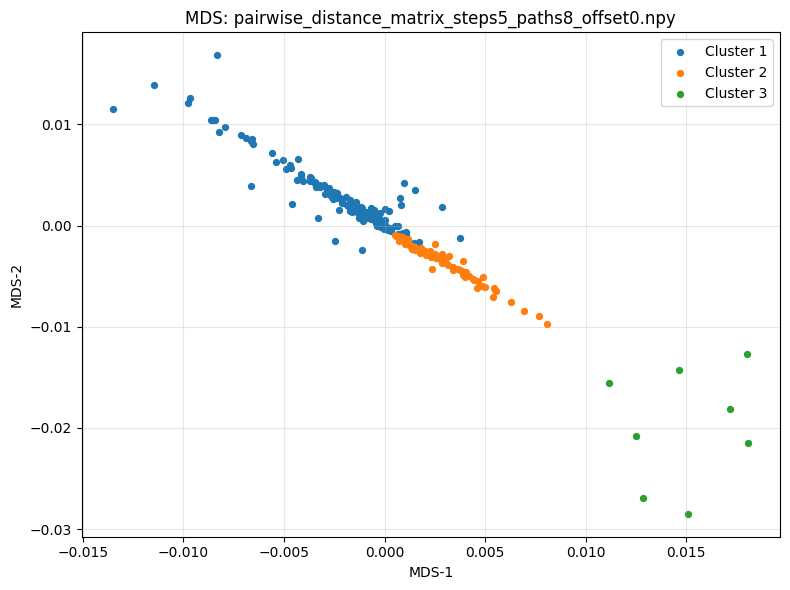

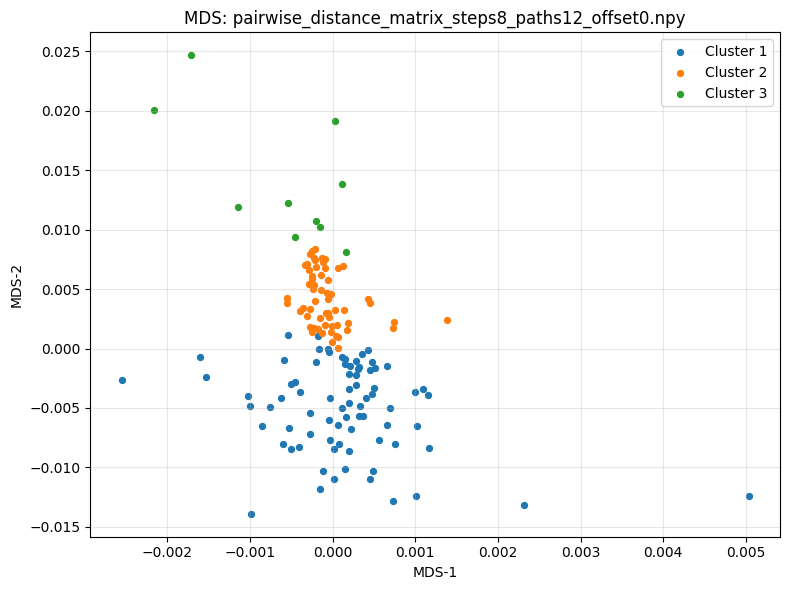

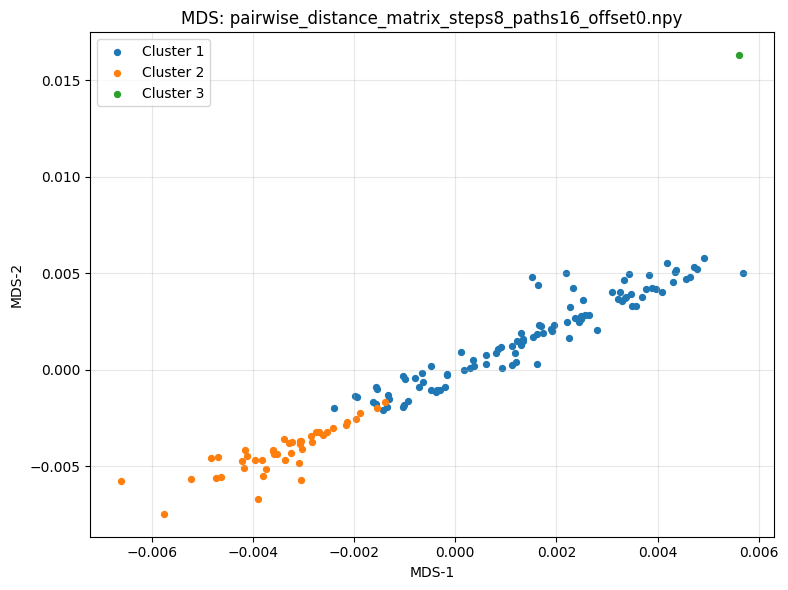

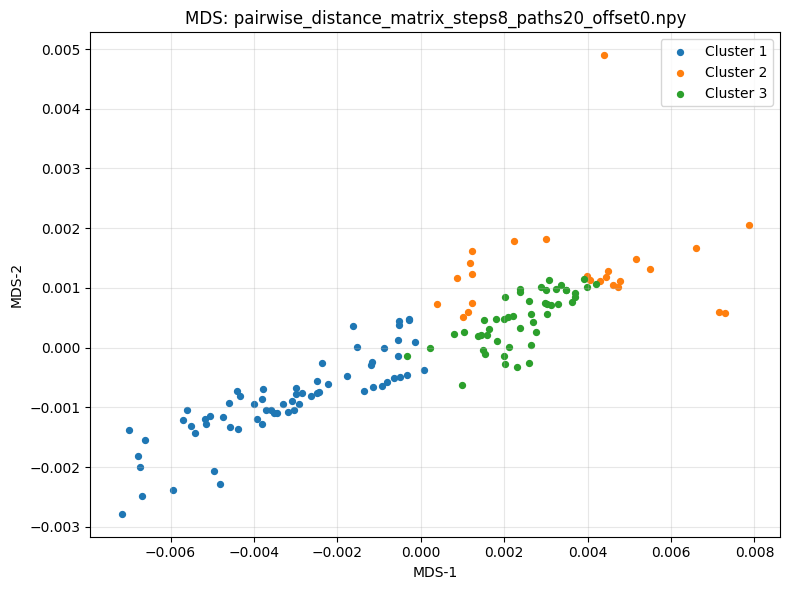

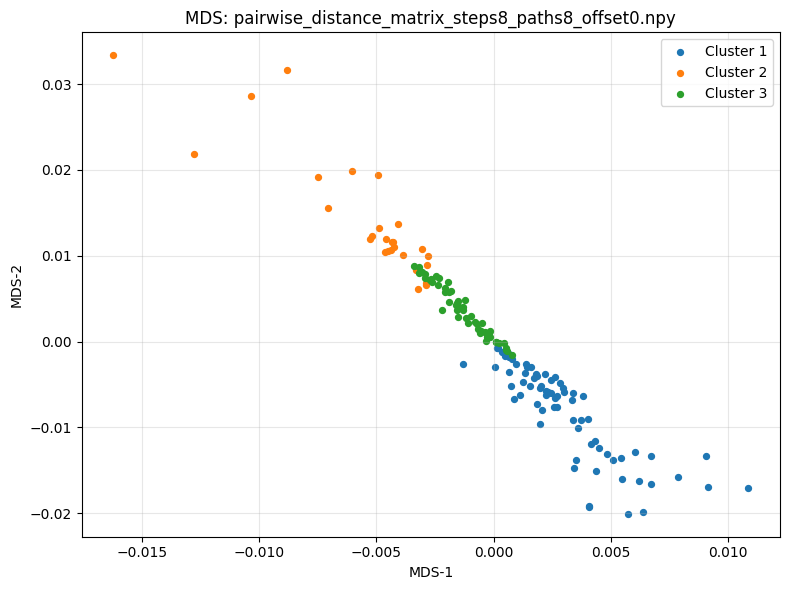

In [58]:
from glob import glob

for path in sorted(glob(str(Path(get_project_root()) / "dataall/pairwise_distance_matrix_steps*_paths*_offset*.npy"))):
    D = load_D(path)
    labels = agglom_precomputed(D, n_clusters=3)
    plot_mds(D, labels, title=f"MDS: {Path(path).name}")
